## Clustering with the Wine Dataset

# Clustering with the Wine Dataset

## Project Overview

This project is about unsupervised machine learning using clustering methods. We have a wine dataset, which contains chemical measurements of different wines. The true wine classes are available in the dataset, but they are not used to train the clustering models. They are used only later to help evaluate how well the clusters match the known wine groups.

## Methods Used

- K Means Clustering
- Hierarchical Clustering
- DBSCAN
- Feature scaling
- Elbow method
- Silhouette score
- PCA visualization
- Cluster interpretation

## Main Goal

The goal is to identify natural groups in the data and evaluate whether the clustering algorithms can recover meaningful wine groupings based only on the feature values.

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

### Load the dataset

In [2]:
wine = load_wine(as_frame=True)

df = wine.frame.copy()

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

### Remove the target variable before training

The target labels are not used for clustering. They are kept only for external evaluation after the clustering models are fitted.

In [4]:
df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

### Define features and true labels

In [5]:
X = df.drop(columns="target")

true_labels = df["target"]

### Scale the features

Clustering is distance based, so scaling is very important. Features with large values can dominate the distance calculation.

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### K-Means clustering

K Means groups observations into a fixed number of clusters. It tries to minimize the distance between each observation and the center of its assigned cluster.

Since the Wine dataset has three known wine classes, we start with three clusters.

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

df[["target", "kmeans_cluster"]].head()

,target,kmeans_cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


#### Evaluate K Means

The silhouette score measures how well separated the clusters are. Higher values are better.

The Davies Bouldin score measures cluster overlap. Lower values are better.

The Calinski Harabasz score measures how dense and well separated the clusters are. Higher values are better.

The Adjusted Rand Index compares the clusters to the true wine labels. It is used only for evaluation because the true labels are not used during clustering.

In [8]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)

print("K Means Clustering Performance")
print("------------------------------")
print(f"Silhouette Score:       {kmeans_silhouette:.3f}")
print(f"Davies Bouldin Score:   {kmeans_db:.3f}")
print(f"Calinski Harabasz Score:{kmeans_ch:.3f}")
print(f"Adjusted Rand Index:    {kmeans_ari:.3f}")

K Means Clustering Performance
------------------------------
Silhouette Score:       0.285
Davies Bouldin Score:   1.389
Calinski Harabasz Score:70.940
Adjusted Rand Index:    0.897


K-Means performs well on this dataset. The high Adjusted Rand Index of 0.897 shows that the predicted clusters closely match the true wine classes. However, the silhouette score of 0.285 suggests that the clusters are only moderately separated, meaning some observations may overlap across groups. Overall, K-Means identifies meaningful structure, but the clusters are not perfectly distinct.

#### Elbow method for choosing K

The elbow method looks for the point where adding more clusters gives only a small improvement. This point is called the elbow. It suggests a reasonable number of clusters.

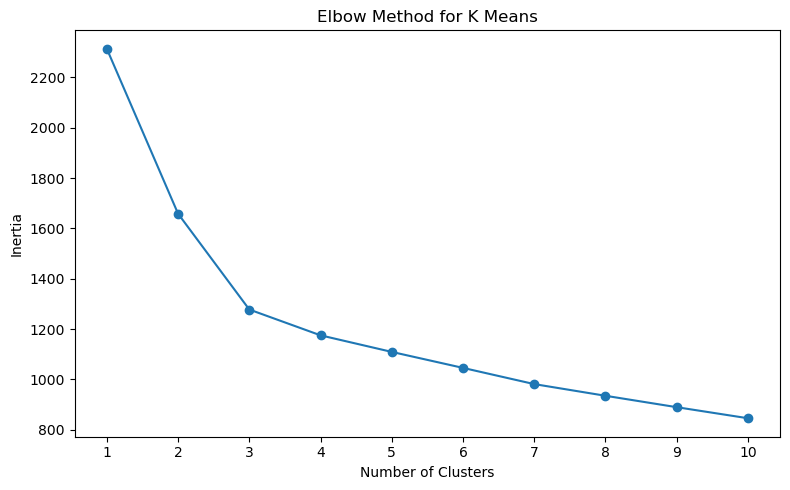

In [9]:
inertia_values = []

k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Means")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Silhouette scores for different K values

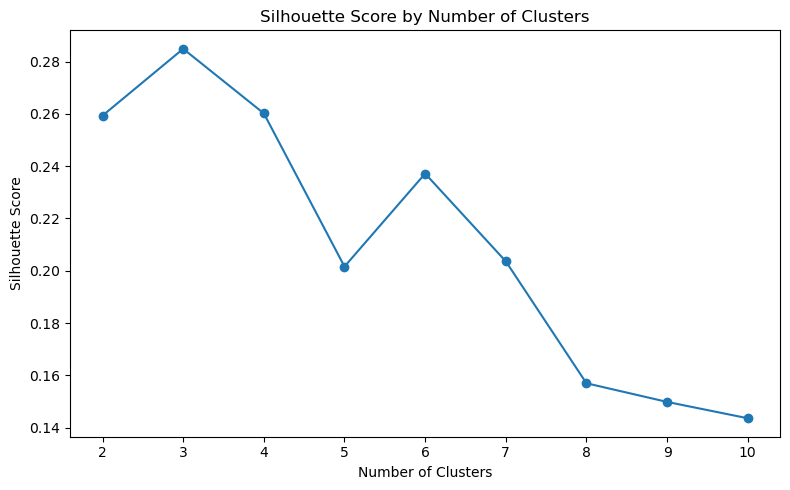

In [10]:
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(k_values)
plt.tight_layout()
plt.show()